In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/mac/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
df_lyrics = pd.read_csv('lyrics_en_es.csv')
print(df_lyrics.shape)

(6813, 5)


#### Clean 

In [3]:
import re
def clean_lyrics_sentiment(text):
    text = str(text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\(.*?\)', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df_lyrics['lyrics_sentiment'] = df_lyrics['lyrics'].apply(clean_lyrics_sentiment)

In [4]:
df_lyrics.head()

,id,Title,Artists_All,language,lyrics,lyrics_sentiment
0,5aAx2yezTd8zXrkmtKl66Z,Starboy,"The Weeknd, Daft Punk",en,"Ayy\n\nI'm tryna put you in the worst mood, ah...","Ayy I'm tryna put you in the worst mood, ah P1..."
1,7BKLCZ1jbUBVqRi2FVlTVw,Closer,"The Chainsmokers, Halsey",en,"Hey, I was doing just fine before I met you\nI...","Hey, I was doing just fine before I met you I ..."
2,4pdPtRcBmOSQDlJ3Fk945m,Let Me Love You,"DJ Snake, Justin Bieber",en,I used to believe\nWe were burnin' on the edge...,I used to believe We were burnin' on the edge ...
3,5MFzQMkrl1FOOng9tq6R9r,Don't Wan Know,"Maroon 5, Kendrick Lamar",en,"Get on my nerves, get in my room\nFirst, she g...","Get on my nerves, get in my room First, she go..."
4,343YBumqHu19cGoGARUTsd,Fake Love,Drake,en,"Yeah, yeah\n\nI've been down so long, it look ...","Yeah, yeah I've been down so long, it look lik..."


In [5]:
df_en = df_lyrics[df_lyrics['language'] == 'en'].reset_index(drop=True)
df_es = df_lyrics[df_lyrics['language'] == 'es'].reset_index(drop=True)

### Vader

In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [7]:
def sentiment_vader(text):
    return SentimentIntensityAnalyzer().polarity_scores(str(text))['compound']

In [8]:
df_es['sentiment_score'] = df_es['lyrics_sentiment'].apply(sentiment_vader)
df_es['sentiment_label'] = pd.cut(df_es['sentiment_score'], bins=3, labels=['negative', 'neutral', 'positive'])

In [9]:
print(df_es.head())

                       id                        Title            Artists_All  \
0  3AEZUABDXNtecAOSC1qTfo   Reggaetón Lento (Bailemos)                   CNCO   
1  7DM4BPaS7uofFul3ywMe46  Vente Pa' Ca (feat. Maluma)           Ricky Martin   
2  3QwBODjSEzelZyVjxPOHdq    Otra vez (feat. J Balvin)          Zion & Lennox   
3  0sXvAOmXgjR2QUqLK1MltU                 La Bicicleta  Carlos Vives, Shakira   
4  5J1c3M4EldCfNxXwrwt8mT                  Traicionera        Sebastian Yatra   

  language                                             lyrics  \
0       es  Qué bien se ve\nMe trae loco su figura (\n¡Fig...   
1       es  Ven, te cuento de una vez\nTu descanso está en...   
2       es  (El sólo verte me dan ganas, eh)\n(Precisament...   
3       es  Nada voy a hacer\nRebuscando en las heridas de...   
4       es  Sebastián Yatra\nYatra, Yatra\n\nTú me dices q...   

                                    lyrics_sentiment  sentiment_score  \
0  Qué bien se ve Me trae loco su figura ( ¡Figur

#### Merge with Main Dataset (to get the stage information)

In [10]:
df_main = pd.read_csv('df_pca.csv')
print(df_main.columns.tolist())

['Week_End', 'Week_Start_Fri', 'Week_Label', 'Weekly_Rank', 'id', 'Title', 'Artists_All', 'Weekly_Points', 'Streams', 'Days_Charted', 'Peak_Rank', 'Stage', 'Year', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', 'Song_URL', 'PC1', 'PC2', 'PC3', 'PC4']


In [11]:
df_es_merged = df_main.merge(df_es[['id', 'sentiment_score', 'sentiment_label']], on='id', how='inner')
es_unique = df_es_merged.drop_duplicates(subset='id')

#### Sentiment by Stage

In [12]:
stage_order = ['Stage 1 (2017-2019)', 'Stage 2 (2020-2022)', 'Stage 3 (2023-2025)']
es_summary = df_es_merged.groupby('Stage')[['sentiment_score']].mean().reindex(stage_order).round(4)

In [13]:
print(es_summary)

                     sentiment_score
Stage                               
Stage 1 (2017-2019)          -0.6062
Stage 2 (2020-2022)          -0.6992
Stage 3 (2023-2025)          -0.5299


#### Plot: English Lyrics Sentiment by Stage

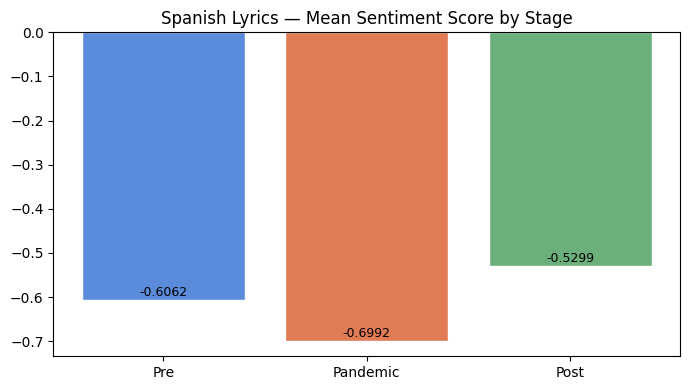

In [14]:
stage_labels = ['Pre', 'Pandemic', 'Post']
colors = ['#5B8CDB', '#E07B54', '#6BAF7A']

fig, ax = plt.subplots(figsize=(7, 4))
vals = es_summary['sentiment_score'].values
bars = ax.bar(stage_labels, vals, color=colors, edgecolor='white')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Spanish Lyrics — Mean Sentiment Score by Stage')
plt.tight_layout()
plt.show()

### TextBlob

In [15]:
from textblob import TextBlob

In [16]:
def sentiment_textblob(text):
    return TextBlob(str(text)).sentiment.polarity

In [17]:
def sentiment_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

In [19]:
df_es['polarity'] = df_es['lyrics_sentiment'].apply(sentiment_textblob)
df_es['subjectivity'] = df_es['lyrics_sentiment'].apply(sentiment_subjectivity)

In [21]:
print(df_es[['Title', 'polarity', 'subjectivity']].head())

                         Title  polarity  subjectivity
0   Reggaetón Lento (Bailemos)     0.625          0.50
1  Vente Pa' Ca (feat. Maluma)     0.000          0.00
2    Otra vez (feat. J Balvin)     0.100          0.65
3                 La Bicicleta     0.000          0.00
4                  Traicionera     0.000          0.00


#### Sentiment by Stage¶

In [22]:
df_es_merged = df_main.merge(df_es[['id', 'polarity', 'subjectivity']], on='id', how='inner')
es_unique = df_es_merged.drop_duplicates(subset='id')

In [23]:
es_summary = es_unique.groupby('Stage')[['polarity', 'subjectivity']].mean().reindex(stage_order).round(4)
print(es_summary)

                     polarity  subjectivity
Stage                                      
Stage 1 (2017-2019)    0.0260        0.3299
Stage 2 (2020-2022)    0.0090        0.3670
Stage 3 (2023-2025)    0.0105        0.2889


#### Plot: English Lyrics Sentiment by Stage¶

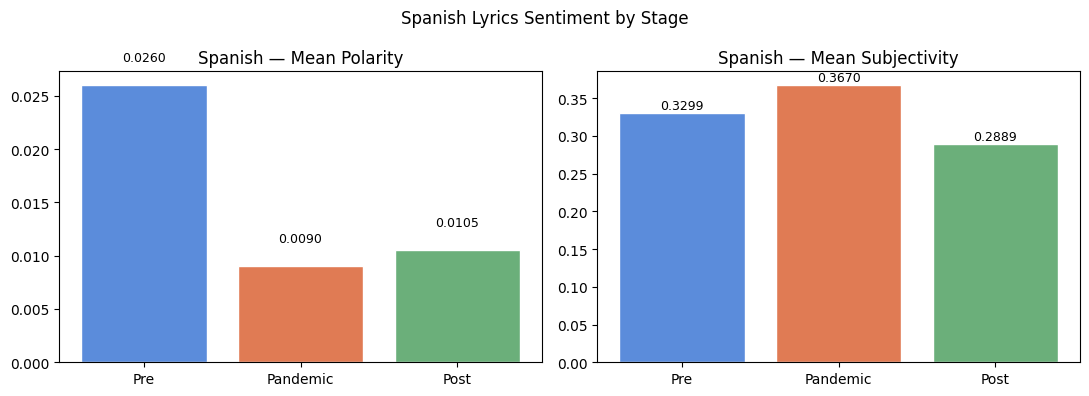

In [28]:
stage_labels = ['Pre', 'Pandemic', 'Post']
colors = ['#5B8CDB', '#E07B54', '#6BAF7A']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes, ['polarity', 'subjectivity'], ['Mean Polarity', 'Mean Subjectivity']):
    vals = es_summary[col].values
    bars = ax.bar(stage_labels, vals, color=colors, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Spanish — {title}')
plt.suptitle('Spanish Lyrics Sentiment by Stage')
plt.tight_layout()
plt.show()

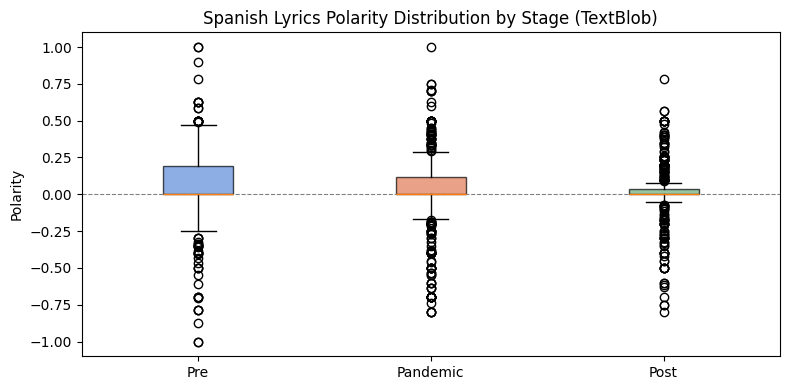

In [27]:
pre_pol = es_unique[es_unique['Stage']=='Stage 1 (2017-2019)']['polarity'].dropna().values
pan_pol = es_unique[es_unique['Stage']=='Stage 2 (2020-2022)']['polarity'].dropna().values
pos_pol = es_unique[es_unique['Stage']=='Stage 3 (2023-2025)']['polarity'].dropna().values

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot([pre_pol, pan_pol, pos_pol], tick_labels=stage_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Polarity')
ax.set_title('Spanish Lyrics Polarity Distribution by Stage (TextBlob)')
plt.tight_layout()
plt.show()